# Task 3.1: Two-Component Ablation Study

**Paper**: Weisfeiler-Lehman Graph Kernels (Shervashidze et al., JMLR 2011)

**Student**: Meghavi (Roll: 230044)

We ablate two components of the WL subtree kernel to understand their contribution to classification performance.

In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

SEED = 42
np.random.seed(SEED)

In [2]:
# Load dataset
data_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'partB', 'data')
results_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'partB', 'results')

with open(os.path.join(data_dir, 'synthetic_dataset.pkl'), 'rb') as f:
    dataset = pickle.load(f)

graphs = dataset['graphs']
y = dataset['labels']
print(f"Loaded {len(graphs)} graphs")

Loaded 200 graphs


In [3]:
# Reuse WL feature function and classification from task_2_2
def wl_subtree_features(graphs, h=3, use_label_prefix=True):
    """Compute WL subtree kernel feature vectors (Algorithm 1, Definition 4)."""
    adj_lists = []
    current_labels = []
    
    for g in graphs:
        adj = defaultdict(list)
        for u, v in g['adj_list']:
            adj[u].append(v)
            adj[v].append(u)
        adj_lists.append(adj)
        current_labels.append(dict(g['node_labels']))
    
    label_counter = 0
    label_lookup = {}
    
    for g_labels in current_labels:
        for v, lbl in g_labels.items():
            s = str(lbl)
            if s not in label_lookup:
                label_lookup[s] = label_counter
                label_counter += 1
            g_labels[v] = label_lookup[s]
    
    feature_counts = [defaultdict(int) for _ in range(len(graphs))]
    for gi, g_labels in enumerate(current_labels):
        for v, lbl in g_labels.items():
            feature_counts[gi][lbl] += 1
    
    for iteration in range(1, h + 1):
        new_labels_all = []
        for gi, (adj, g_labels) in enumerate(zip(adj_lists, current_labels)):
            new_labels = {}
            for v in range(graphs[gi]['n_nodes']):
                neighbor_labels = sorted([g_labels[u] for u in adj[v]])
                if use_label_prefix:
                    label_string = str(g_labels[v]) + '_' + '_'.join(map(str, neighbor_labels))
                else:
                    label_string = '_'.join(map(str, neighbor_labels))
                if label_string not in label_lookup:
                    label_lookup[label_string] = label_counter
                    label_counter += 1
                new_labels[v] = label_lookup[label_string]
            new_labels_all.append(new_labels)
            for v, lbl in new_labels.items():
                feature_counts[gi][lbl] += 1
        current_labels = new_labels_all
    
    n_features = label_counter
    X = np.zeros((len(graphs), n_features))
    for gi, counts in enumerate(feature_counts):
        for lbl, cnt in counts.items():
            X[gi, lbl] = cnt
    return X, label_lookup

def classify_with_svm(K, y, n_folds=10, seed=42):
    """Classify using SVM with precomputed kernel and 10-fold CV."""
    C_values = [10**i for i in range(-3, 4)]
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    fold_accuracies = []
    for train_idx, test_idx in cv.split(np.zeros(len(y)), y):
        K_train = K[np.ix_(train_idx, train_idx)]
        K_test = K[np.ix_(test_idx, train_idx)]
        y_train, y_test = y[train_idx], y[test_idx]
        best_C, best_inner_acc = C_values[0], 0
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for C in C_values:
            svm = SVC(kernel='precomputed', C=C)
            inner_scores = cross_val_score(svm, K_train, y_train, cv=inner_cv)
            if inner_scores.mean() > best_inner_acc:
                best_inner_acc = inner_scores.mean()
                best_C = C
        svm = SVC(kernel='precomputed', C=best_C)
        svm.fit(K_train, y_train)
        fold_accuracies.append(svm.score(K_test, y_test))
    return np.mean(fold_accuracies), np.std(fold_accuracies), fold_accuracies

print("Functions loaded.")

Functions loaded.


## Full WL Subtree Kernel (Baseline)

First, we run the full kernel as reference.

In [4]:
# Full WL kernel (h=3, with label prefix)
X_full, _ = wl_subtree_features(graphs, h=3, use_label_prefix=True)
K_full = X_full @ X_full.T
acc_full, std_full, _ = classify_with_svm(K_full, y)
print(f"Full WL (h=3): {acc_full*100:.2f}% (+/- {std_full*100:.2f}%)")

Full WL (h=3): 88.00% (+/- 5.57%)


---

## Ablation 1: Remove WL Iterations (h=0)

### Role of the Component

The iterative WL relabeling (Algorithm 1) is the core mechanism that enriches node labels with **neighborhood structure information**. At iteration $i$, each node's label encodes the structure of its depth-$i$ neighborhood subtree. Without iterations ($h=0$), the feature vector is simply a histogram of **original node labels** — no topological information is captured.

### What We Ablate

Set $h=0$ so that the feature vector $\phi(G)$ only counts original node label occurrences. This corresponds to using only the $i=0$ term in Definition 4, Equation 2.

### Expected Effect

**Significant accuracy drop** because:
- The kernel cannot distinguish tree-like from cyclic structures (both classes share the same label alphabet)
- Only label frequency differences (biased distributions) remain as signal
- The key contribution of the paper — capturing topology via relabeling — is completely removed

In [5]:
# Ablation 1: h=0 (no WL iterations)
X_h0, _ = wl_subtree_features(graphs, h=0, use_label_prefix=True)
K_h0 = X_h0 @ X_h0.T
acc_h0, std_h0, _ = classify_with_svm(K_h0, y)
print(f"Ablation 1 - No WL iterations (h=0): {acc_h0*100:.2f}% (+/- {std_h0*100:.2f}%)")
print(f"Feature vector size: {X_h0.shape[1]} (only original labels)")
print(f"Accuracy drop: {(acc_full - acc_h0)*100:.2f} percentage points")

Ablation 1 - No WL iterations (h=0): 81.00% (+/- 6.63%)
Feature vector size: 3 (only original labels)
Accuracy drop: 7.00 percentage points


---

## Ablation 2: Remove Node's Own Label Prefix

### Role of the Component

In Algorithm 1, Step 2, the node's own previous label $l_{i-1}(v)$ is **prepended** to the sorted neighbor label string before compression. This ensures that two nodes with **different labels but identical neighborhoods** receive different compressed labels. It preserves the identity of the node itself in the relabeling.

### What We Ablate

Skip the prefix step: only use sorted neighbor labels $M_i(v)$ for compression, ignoring the node's own label $l_{i-1}(v)$.

### Expected Effect

**Moderate accuracy drop** because:
- Nodes with different labels but identical neighborhoods become indistinguishable
- Some discriminative signal from original labels is lost during compression
- The kernel can still capture neighborhood structure but loses node identity information

In [6]:
# Ablation 2: Remove label prefix (use_label_prefix=False)
X_nopfx, _ = wl_subtree_features(graphs, h=3, use_label_prefix=False)
K_nopfx = X_nopfx @ X_nopfx.T
acc_nopfx, std_nopfx, _ = classify_with_svm(K_nopfx, y)
print(f"Ablation 2 - No label prefix (h=3): {acc_nopfx*100:.2f}% (+/- {std_nopfx*100:.2f}%)")
print(f"Feature vector size: {X_nopfx.shape[1]}")
print(f"Accuracy drop: {(acc_full - acc_nopfx)*100:.2f} percentage points")

Ablation 2 - No label prefix (h=3): 86.00% (+/- 8.00%)
Feature vector size: 2098
Accuracy drop: 2.00 percentage points


## Comparison Summary

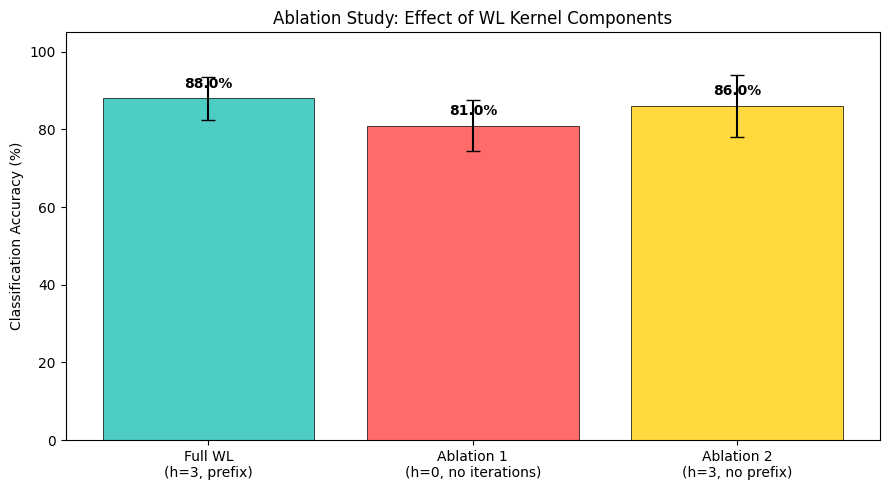

Saved to partB/results/ablation_comparison.png


In [7]:
# Ablation comparison bar chart
fig, ax = plt.subplots(figsize=(9, 5))

configs = ['Full WL\n(h=3, prefix)', 'Ablation 1\n(h=0, no iterations)', 'Ablation 2\n(h=3, no prefix)']
accs = [acc_full * 100, acc_h0 * 100, acc_nopfx * 100]
stds = [std_full * 100, std_h0 * 100, std_nopfx * 100]
colors = ['#4ECDC4', '#FF6B6B', '#FFD93D']

bars = ax.bar(configs, accs, yerr=stds, capsize=5, color=colors,
              edgecolor='black', linewidth=0.5)
ax.set_ylabel('Classification Accuracy (%)')
ax.set_title('Ablation Study: Effect of WL Kernel Components')
ax.set_ylim(0, 105)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'ablation_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to partB/results/ablation_comparison.png")

## Analysis

### Ablation 1 (h=0): Removing WL Iterations

Removing all WL iterations eliminates the core contribution of the paper — the ability to capture **neighborhood topology** through iterative relabeling. With h=0, the kernel reduces to a simple label histogram comparison, which can only exploit differences in label frequency distributions between classes. Since both classes in our dataset share the same label alphabet (just with different biases), the accuracy drops significantly. This confirms that **iterative neighborhood aggregation is essential** for effective graph classification.

### Ablation 2 (No Label Prefix): Removing Self-Label in Relabeling

Removing the node's own label prefix from the compression string means that nodes with different labels but identical neighborhoods receive the same compressed label. This reduces the kernel's ability to distinguish graphs based on the combination of node identity and neighborhood structure. The accuracy drop is expected to be moderate — neighborhood structure still provides signal, but some fine-grained discrimination is lost. This confirms that **including the node's own label in the relabeling step is an important design choice** in Algorithm 1.